In [1]:
import sys
from pathlib import Path
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F

def find_repo_root(start_path=None):
    current = (start_path or Path.cwd()).resolve()
    while True:
        if (current / "data").is_dir() and (current / "data_setup").is_dir():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise RuntimeError("Could not locate necst-torch root directory")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from data_setup.dataloader import load_binarized_mnist  # new API

# download happens inside the loader if missing
train_ds, val_ds, test_ds = load_binarized_mnist(REPO_ROOT / "data" / "BinaryMNIST", download=True)

binary_train_loader = DataLoader(train_ds, batch_size=100, shuffle=True)
binary_valid_loader = DataLoader(val_ds, batch_size=100, shuffle=False)
binary_test_loader  = DataLoader(test_ds, batch_size=100, shuffle=False)

# quick sanity check
bin_batch = next(iter(binary_train_loader))
print("BinaryMNIST batch shape:", bin_batch.shape, "min/max:", bin_batch.min().item(), bin_batch.max().item())


BinaryMNIST batch shape: torch.Size([100, 1, 28, 28]) min/max: 0.0 1.0


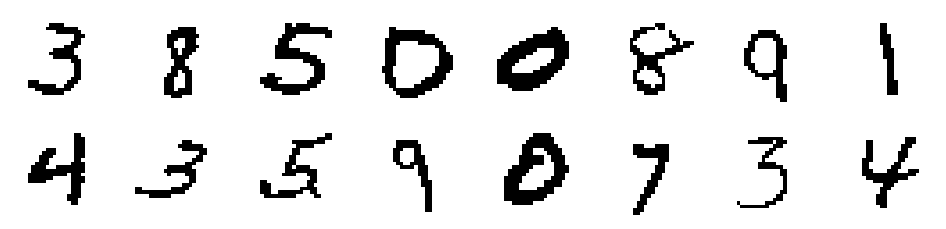

In [2]:
import matplotlib.pyplot as plt

def plot_binary_rows(data_loader, n_rows=2, n_cols=8):
    batch = next(iter(data_loader))
    imgs = batch[0] if isinstance(batch, (list, tuple)) else batch  # handles (imgs, labels) or imgs
    imgs = imgs[: n_rows * n_cols].detach().cpu()
    px = int(imgs.shape[-1] ** 0.5) if imgs.dim() == 2 else imgs.shape[-2]
    imgs = imgs.view(-1, px, px)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.2, n_rows * 1.2))
    for idx, img in enumerate(imgs):
        r, c = divmod(idx, n_cols)
        axes[r, c].imshow(img, cmap="gray_r", vmin=0, vmax=1)
        axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()

plot_binary_rows(binary_train_loader)
